# 02 - CLIP Baseline Retrieval

## 1. Import libraries and define paths

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

# Dinh nghia duong dan tu notebook ve root project.
PROJECT_ROOT = Path("..").resolve()
METADATA_PATH = PROJECT_ROOT / "data/processed/metadata.json"
EMBEDDING_OUTPUT_PATH = PROJECT_ROOT / "data/processed/clip_image_embeddings_subset.npy"
SUBSET_METADATA_OUTPUT_PATH = PROJECT_ROOT / "data/processed/clip_subset_metadata.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-base-patch32"

d:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load metadata

In [2]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay metadata: {METADATA_PATH}")

with METADATA_PATH.open("r", encoding="utf-8") as f:
    metadata = json.load(f)

print(f"So item metadata: {len(metadata)}")
print(metadata[0])

# Kiem tra file anh dau tien trong metadata.
sample_image_path = PROJECT_ROOT / metadata[0]["image_path"]
if not sample_image_path.exists():
    raise FileNotFoundError(f"Khong tim thay anh mau: {sample_image_path}")

print(f"Anh mau ton tai: {sample_image_path}")

So item metadata: 31782
{'image_id': '1000092795.jpg', 'image_path': 'data/raw/Images/1000092795.jpg', 'captions': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young , White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .']}
Anh mau ton tai: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\raw\Images\1000092795.jpg


## 3. Create small subset for baseline

In [3]:
SUBSET_SIZE = 1000
subset_metadata = metadata[:SUBSET_SIZE]

print(f"So anh trong subset: {len(subset_metadata)}")

# Dam bao tat ca anh trong subset deu ton tai.
missing_images = [
    item["image_path"]
    for item in subset_metadata
    if not (PROJECT_ROOT / item["image_path"]).exists()
]

if missing_images:
    raise FileNotFoundError(
        "Co anh trong subset khong ton tai. "
        f"Vi du: {missing_images[:5]}"
    )

print("Tat ca anh trong subset deu ton tai.")

So anh trong subset: 1000
Tat ca anh trong subset deu ton tai.


## 4. Load CLIP model

In [4]:
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 30110.08it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Model: openai/clip-vit-base-patch32


## 5. Encode images

In [5]:
def get_feature_tensor(model_output):
    """Lay tensor embedding tu output cua transformers o cac phien ban khac nhau."""
    if isinstance(model_output, torch.Tensor):
        return model_output
    if hasattr(model_output, "pooler_output"):
        return model_output.pooler_output
    if hasattr(model_output, "last_hidden_state"):
        return model_output.last_hidden_state[:, 0]
    raise TypeError(f"Khong ho tro kieu output: {type(model_output)}")


def encode_images(metadata_items, batch_size=32):
    """Encode anh bang CLIP image encoder va normalize embedding."""
    all_embeddings = []

    for start_idx in tqdm(range(0, len(metadata_items), batch_size), desc="Encoding images"):
        batch_items = metadata_items[start_idx:start_idx + batch_size]
        images = []

        for item in batch_items:
            image_path = PROJECT_ROOT / item["image_path"]
            image = Image.open(image_path).convert("RGB")
            images.append(image)

        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

        with torch.no_grad():
            image_features = get_feature_tensor(model.get_image_features(**inputs))
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        all_embeddings.append(image_features.cpu().numpy())

    return np.concatenate(all_embeddings, axis=0)


image_embeddings = encode_images(subset_metadata, batch_size=32)
print("Image embeddings shape:", image_embeddings.shape)

np.save(EMBEDDING_OUTPUT_PATH, image_embeddings)

with SUBSET_METADATA_OUTPUT_PATH.open("w", encoding="utf-8") as f:
    json.dump(subset_metadata, f, ensure_ascii=False, indent=2)

print(f"Da luu embeddings tai: {EMBEDDING_OUTPUT_PATH}")
print(f"Da luu subset metadata tai: {SUBSET_METADATA_OUTPUT_PATH}")

Encoding images: 100%|██████████| 32/32 [00:07<00:00,  4.01it/s]

Image embeddings shape: (1000, 512)
Da luu embeddings tai: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_image_embeddings_subset.npy
Da luu subset metadata tai: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_subset_metadata.json


## 6. Encode text query

In [6]:
def encode_text(query):
    """Encode text query bang CLIP text encoder va normalize embedding."""
    inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True)
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    with torch.no_grad():
        text_features = get_feature_tensor(model.get_text_features(**inputs))
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features.squeeze(0).cpu().numpy()

## 7. Retrieve top-k images

In [7]:
def retrieve(query, image_embeddings, metadata_items, top_k=5):
    """Tim top-k anh bang cosine similarity brute-force."""
    text_embedding = encode_text(query)

    # Embeddings da normalize nen inner product tuong duong cosine similarity.
    scores = image_embeddings @ text_embedding
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        item = metadata_items[idx]
        results.append(
            {
                "rank": rank,
                "image_id": item["image_id"],
                "image_path": item["image_path"],
                "score": float(scores[idx]),
                "captions": item["captions"],
            }
        )

    return results

## 8. Visualize retrieval results

In [8]:
def show_results(results):
    """Hien thi anh ket qua kem rank, score va caption dau tien."""
    num_results = len(results)
    if num_results == 0:
        print("Khong co ket qua de hien thi.")
        return

    fig, axes = plt.subplots(1, num_results, figsize=(4 * num_results, 4))
    if num_results == 1:
        axes = [axes]

    for ax, result in zip(axes, results):
        image_path = PROJECT_ROOT / result["image_path"]
        image = Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"#{result['rank']} | {result['score']:.3f}\n{result['image_id']}",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

    for result in results:
        print(f"#{result['rank']} {result['image_id']} | score={result['score']:.4f}")
        print(f"Caption: {result['captions'][0]}")

## 9. Test with manual queries

Query: a dog running on the grass
#1 | 1019077836.jpg | score=0.3213 | Large brown dog running away from the sprinkler in the grass .
#2 | 1164131282.jpg | score=0.3080 | A gray dog beside a black and white dog running in green grass .
#3 | 1009434119.jpg | score=0.3067 | A black and white dog is running in a grassy garden surrounded by a white fence .
#4 | 1119418776.jpg | score=0.3046 | A brown , black and white dog is running through a large field with its mouth open .
#5 | 1240297429.jpg | score=0.3026 | A dog is wearing a red number 6 and running through a field of green grass while being chased by a bird .


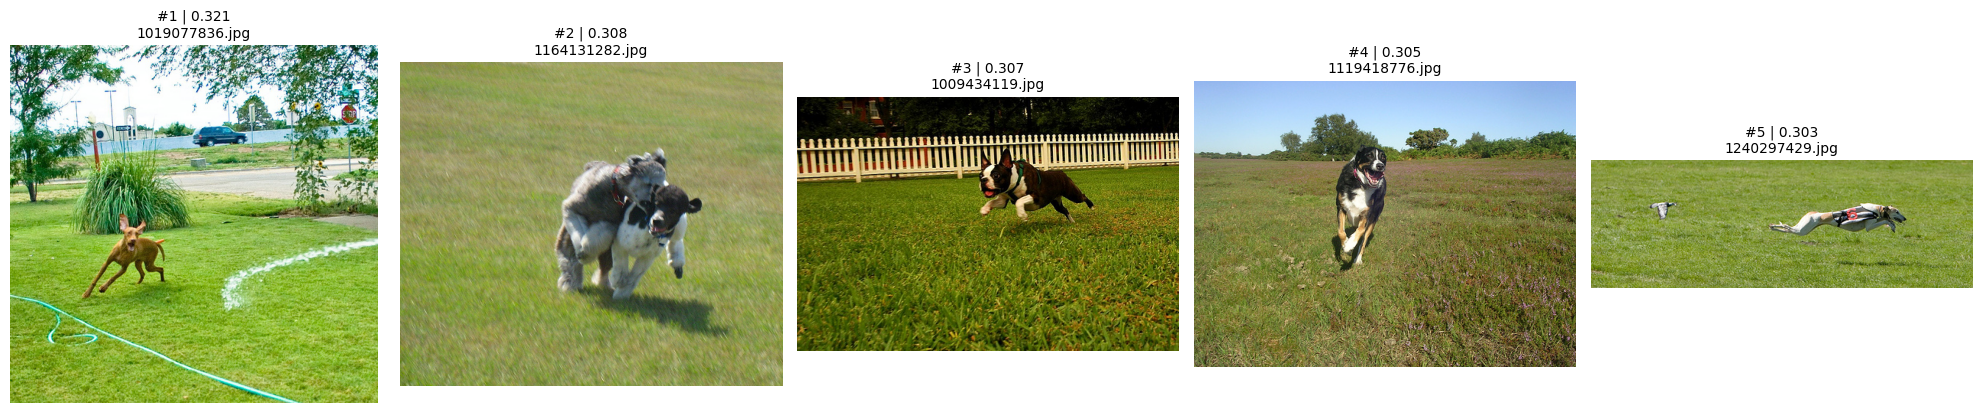

#1 1019077836.jpg | score=0.3213
Caption: Large brown dog running away from the sprinkler in the grass .
#2 1164131282.jpg | score=0.3080
Caption: A gray dog beside a black and white dog running in green grass .
#3 1009434119.jpg | score=0.3067
Caption: A black and white dog is running in a grassy garden surrounded by a white fence .
#4 1119418776.jpg | score=0.3046
Caption: A brown , black and white dog is running through a large field with its mouth open .
#5 1240297429.jpg | score=0.3026
Caption: A dog is wearing a red number 6 and running through a field of green grass while being chased by a bird .
Query: a man riding a bicycle
#1 | 101001624.jpg | score=0.3027 | The " white out " conditions of snow on the ground seem to almost obliverate the details of a man dressed for the cold weather in a heavy jacket and red hat riding a bicycle in a suburban neighborhood .
#2 | 1142847777.jpg | score=0.3005 | A woman in a blue helmet and brown shorts rides her bike on a busy street .
#3 | 11

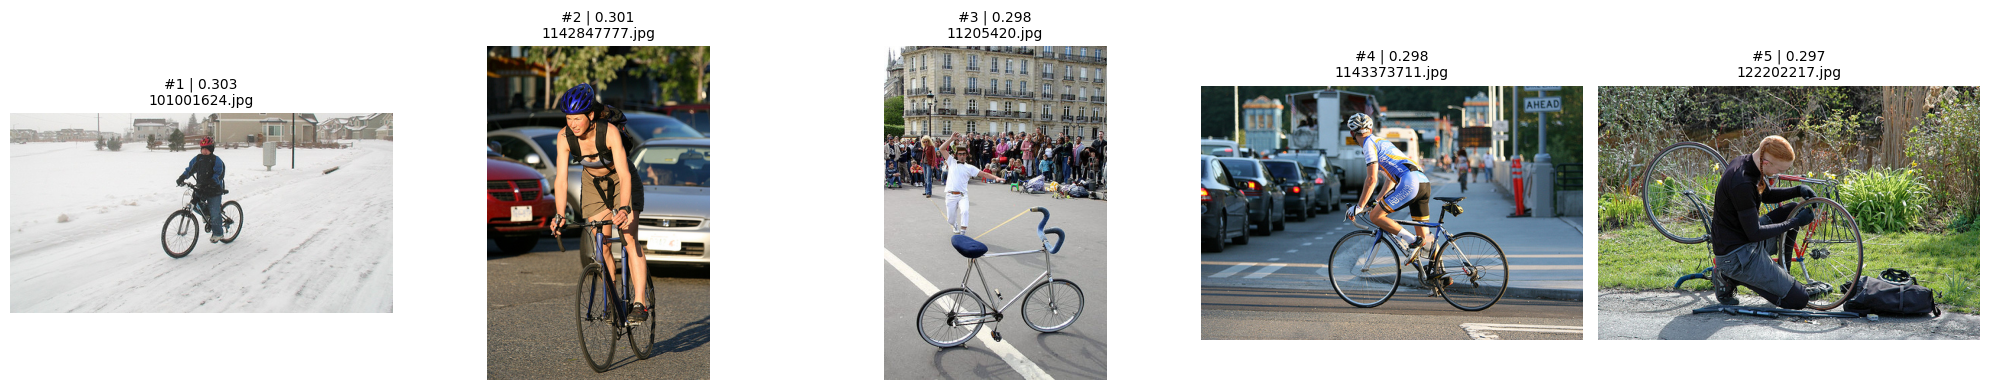

#1 101001624.jpg | score=0.3027
Caption: The " white out " conditions of snow on the ground seem to almost obliverate the details of a man dressed for the cold weather in a heavy jacket and red hat riding a bicycle in a suburban neighborhood .
#2 1142847777.jpg | score=0.3005
Caption: A woman in a blue helmet and brown shorts rides her bike on a busy street .
#3 11205420.jpg | score=0.2982
Caption: A man dressed in white walks a yellow rope on the ground that is attached to the handlebars of a bicycle .
#4 1143373711.jpg | score=0.2978
Caption: A man in blue and white biking gear rides down a busy street .
#5 122202217.jpg | score=0.2966
Caption: The journey is temporarily delayed by mechanical malfunctions .
Query: children playing outside
#1 | 125635185.jpg | score=0.3339 | Three children are playing outdoors , two of them on a metal barrel swing .
#2 | 1006452823.jpg | score=0.3319 | two children , a girl and a boy are practicing their writing .
#3 | 1295719054.jpg | score=0.3150 | 

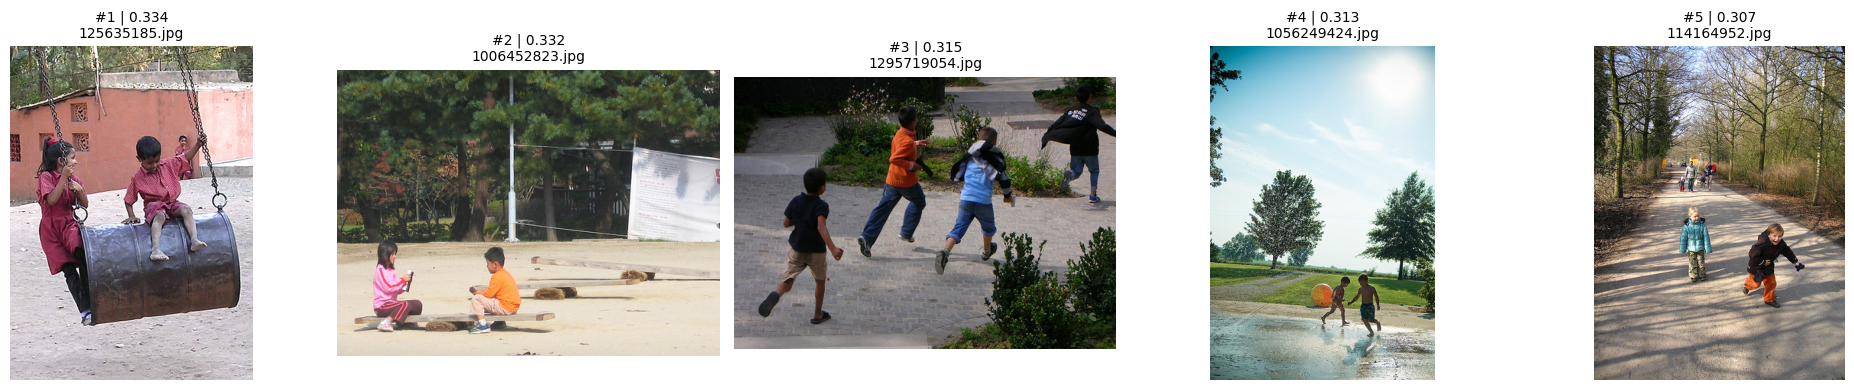

#1 125635185.jpg | score=0.3339
Caption: Three children are playing outdoors , two of them on a metal barrel swing .
#2 1006452823.jpg | score=0.3319
Caption: two children , a girl and a boy are practicing their writing .
#3 1295719054.jpg | score=0.3150
Caption: A child in a black cape is being chased by other children .
#4 1056249424.jpg | score=0.3131
Caption: Two boys , one with a yellow and orange ball , play in some water in front of a field .
#5 114164952.jpg | score=0.3067
Caption: Family taking a winter walk in a park path while two of the children run ahead of the family .
Query: a group of people sitting at a table
#1 | 107582366.jpg | score=0.3046 | A group of people sit around a table outside on a porch at night .
#2 | 1003420127.jpg | score=0.2973 | A group of adults , inside a home , sitting on chairs arranged in a circle , playing a type of musical instruments .
#3 | 108656820.jpg | score=0.2931 | A group of people are either standing or sitting , some are wearing hats 

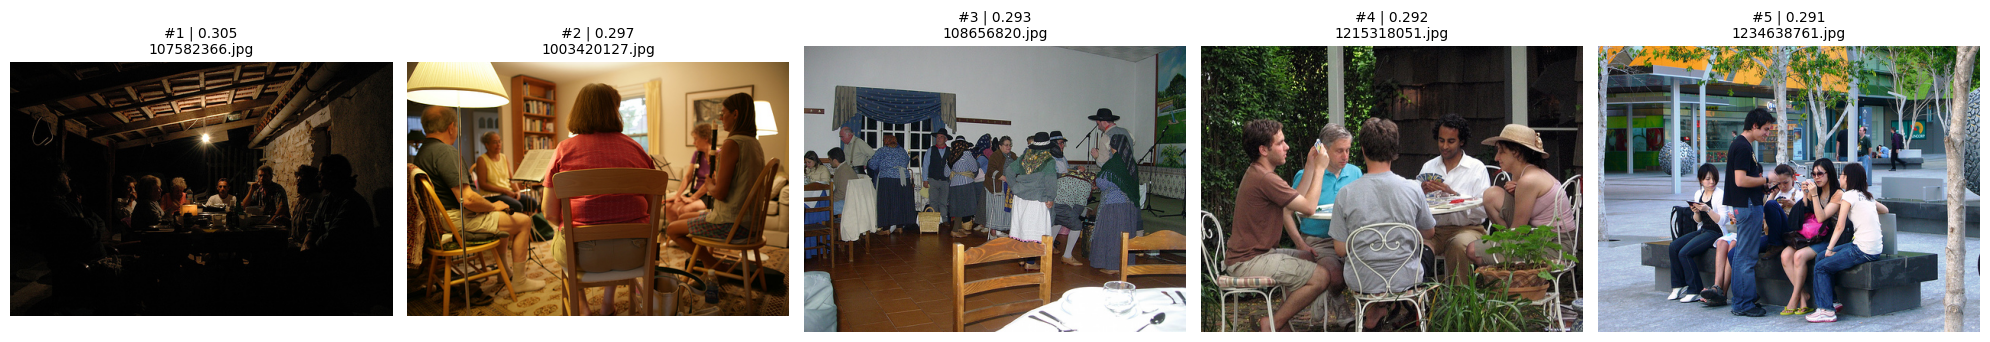

#1 107582366.jpg | score=0.3046
Caption: A group of people sit around a table outside on a porch at night .
#2 1003420127.jpg | score=0.2973
Caption: A group of adults , inside a home , sitting on chairs arranged in a circle , playing a type of musical instruments .
#3 108656820.jpg | score=0.2931
Caption: A group of people are either standing or sitting , some are wearing hats and scarves , while some are not .
#4 1215318051.jpg | score=0.2923
Caption: Five adults are playing cards while sitting outside at a picnic table in their backyard .
#5 1234638761.jpg | score=0.2907
Caption: A man in a black shirt shares something with a group of girls sitting on a bench .


In [9]:
queries = [
    "a dog running on the grass",
    "a man riding a bicycle",
    "children playing outside",
    "a group of people sitting at a table",
]

for query in queries:
    print("=" * 80)
    print(f"Query: {query}")
    results = retrieve(query, image_embeddings, subset_metadata, top_k=5)

    for result in results:
        print(
            f"#{result['rank']} | {result['image_id']} | "
            f"score={result['score']:.4f} | {result['captions'][0]}"
        )

    show_results(results)

## 10. Quick sanity test using an existing caption

In [10]:
test_item = subset_metadata[0]
query = test_item["captions"][0]
results = retrieve(query, image_embeddings, subset_metadata, top_k=10)

ground_truth_image_id = test_item["image_id"]
retrieved_image_ids = [result["image_id"] for result in results]
hit_at_10 = ground_truth_image_id in retrieved_image_ids

print(f"Query caption: {query}")
print(f"Ground-truth image_id: {ground_truth_image_id}")
print(f"Retrieved image_ids: {retrieved_image_ids}")
print(f"Hit@10: {hit_at_10}")

Query caption: Two young guys with shaggy hair look at their hands while hanging out in the yard .
Ground-truth image_id: 1000092795.jpg
Retrieved image_ids: ['1000092795.jpg', '1053116826.jpg', '1177994172.jpg', '128479788.jpg', '131114016.jpg', '1131804997.jpg', '128404184.jpg', '1269470943.jpg', '109380144.jpg', '1215318051.jpg']
Hit@10: True
